In [ ]:
import io
import sys
import itertools
import numpy as np
from collections import defaultdict
from gym.envs.toy_text import discrete

## Environment

In [ ]:
UP = 0
RIGHT = 1
DOWN = 2
LEFT = 3

class GridworldEnv(discrete.DiscreteEnv):
    """
    Grid World environment from Sutton's Reinforcement Learning book chapter 4.
    You are an agent on an MxN grid and your goal is to reach the terminal
    state at the top left or the bottom right corner.
    For example, a 4x4 grid looks as follows:
    T  o  o  o
    o  x  o  o
    o  o  o  o
    o  o  o  T
    x is your position and T are the two terminal states.
    You can take actions in each direction (UP=0, RIGHT=1, DOWN=2, LEFT=3).
    Actions going off the edge leave you in your current state.
    You receive a reward of -1 at each step until you reach a terminal state.
    """

    metadata = {'render.modes': ['human', 'ansi']}

    def __init__(self, shape=[4,4]):
        if not isinstance(shape, (list, tuple)) or not len(shape) == 2:
            raise ValueError('shape argument must be a list/tuple of length 2')

        self.shape = shape

        nS = np.prod(shape)
        nA = 4

        MAX_Y = shape[0]
        MAX_X = shape[1]

        P = {}
        grid = np.arange(nS).reshape(shape)
        it = np.nditer(grid, flags=['multi_index'])

        while not it.finished:
            s = it.iterindex
            y, x = it.multi_index

            # P[s][a] = (prob, next_state, reward, is_done)
            P[s] = {a : [] for a in range(nA)}

            is_done = lambda s: s == 0 or s == (nS - 1)
            reward = 0.0 if is_done(s) else -1.0

            # We're stuck in a terminal state
            if is_done(s):
                P[s][UP] = [(1.0, s, reward, True)]
                P[s][RIGHT] = [(1.0, s, reward, True)]
                P[s][DOWN] = [(1.0, s, reward, True)]
                P[s][LEFT] = [(1.0, s, reward, True)]
            # Not a terminal state
            else:
                ns_up = s if y == 0 else s - MAX_X
                ns_right = s if x == (MAX_X - 1) else s + 1
                ns_down = s if y == (MAX_Y - 1) else s + MAX_X
                ns_left = s if x == 0 else s - 1
                P[s][UP] = [(1.0, ns_up, reward, is_done(ns_up))]
                P[s][RIGHT] = [(1.0, ns_right, reward, is_done(ns_right))]
                P[s][DOWN] = [(1.0, ns_down, reward, is_done(ns_down))]
                P[s][LEFT] = [(1.0, ns_left, reward, is_done(ns_left))]

            it.iternext()

        # Initial state distribution is uniform
        isd = np.ones(nS) / nS

        # We expose the model of the environment for educational purposes
        # This should not be used in any model-free learning algorithm
        self.P = P

        super(GridworldEnv, self).__init__(nS, nA, P, isd)

    def render(self, mode='human', close=False):
        """ Renders the current gridworld layout
         For example, a 4x4 grid with the mode="human" looks like:
            T  o  o  o
            o  x  o  o
            o  o  o  o
            o  o  o  T
        where x is your position and T are the two terminal states.
        """
        if close:
            return

        outfile = io.StringIO() if mode == 'ansi' else sys.stdout

        grid = np.arange(self.nS).reshape(self.shape)
        it = np.nditer(grid, flags=['multi_index'])
        while not it.finished:
            s = it.iterindex
            y, x = it.multi_index

            if self.s == s:
                output = " x "
            elif s == 0 or s == self.nS - 1:
                output = " T "
            else:
                output = " o "

            if x == 0:
                output = output.lstrip()
            if x == self.shape[1] - 1:
                output = output.rstrip()

            outfile.write(output)

            if x == self.shape[1] - 1:
                outfile.write("\n")

            it.iternext()

In [ ]:
env = GridworldEnv(shape=[4,4])

## Q-learning Algorithm

Recall the Bellman optimality equation for Q-function:

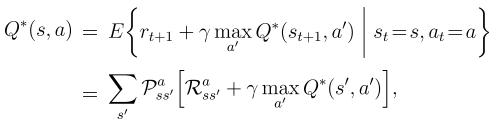

If we update the Q-function towards the target (term inside the expectation) in the above equation, it results in the following update equation:

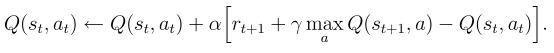

Note that neither the Bellman equation nor the update rule mentions the policy. Thus, Q-learning is called an "off-policy" algorithm which is a very powerful property because it allows the state-action transitions to come from any policy.

The procedural form of the algorithm is as follows:

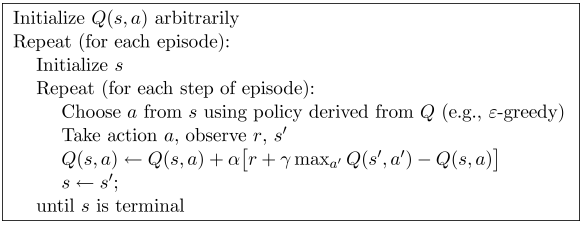

In [ ]:
def make_epsilon_greedy_policy(Q, epsilon, nA):
    """
    Creates an epsilon-greedy policy based on a given Q-function and epsilon.
    
    Args:
        Q: A dictionary that maps from state -> action-values.
            Each value is a numpy array of length nA (see below)
        epsilon: The probability to select a random action. Float between 0 and 1.
        nA: Number of actions in the environment.
    
    Returns:
        A function that takes the observation as an argument and returns
        the probabilities for each action in the form of a numpy array of length nA.
    
    """
    def policy_fn(observation):
        A = np.ones(nA, dtype=float) * epsilon / nA
        best_action = np.argmax(Q[observation])
        A[best_action] += (1.0 - epsilon)
        return A
    return policy_fn

In [ ]:
def q_learning(env, num_episodes, discount_factor=1.0, alpha=0.5, epsilon=0.1):
    """
    Q-Learning algorithm: Off-policy TD control. Finds the optimal greedy policy
    while following an epsilon-greedy policy
    
    Args:
        env: OpenAI environment.
        num_episodes: Number of episodes to run for.
        discount_factor: Gamma discount factor.
        alpha: TD learning rate.
        epsilon: Chance to sample a random action. Float between 0 and 1.
    
    Returns:
        A tuple (Q, episode_lengths).
        Q is the optimal action-value function, a dictionary mapping state -> action values.
    """
    
    # The final action-value function.
    # A nested dictionary that maps state -> (action -> action-value).
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    
    # The policy we're following
    policy = make_epsilon_greedy_policy(Q, epsilon, env.action_space.n)
    
    for i_episode in range(num_episodes):
        # Print out which episode we're on, useful for debugging.
        if (i_episode + 1) % 100 == 0:
            print("\rEpisode {}/{}.".format(i_episode + 1, num_episodes), end="")
            sys.stdout.flush()
        
        # Reset the environment and pick the first action
        state = env.reset()
        
        # One step in the environment
        # total_reward = 0.0
        for t in itertools.count():
            
            # Take a step
            action_probs = policy(state)
            action = np.random.choice(np.arange(len(action_probs)), p=action_probs)
            next_state, reward, done, _ = env.step(action)
            
            # TD Update
            best_next_action = np.argmax(Q[next_state])    
            td_target = reward + discount_factor * Q[next_state][best_next_action]
            td_delta = td_target - Q[state][action]
            Q[state][action] += alpha * td_delta
                
            if done:
                break
                
            state = next_state
    
    return Q

In [ ]:
Q = q_learning(env, 1000)

Episode 1000/1000.

In [ ]:
v = np.array([Q[s].max() for s in range(env.nS)])

In [ ]:
v.reshape(env.shape)

array([[ 0.        , -1.        , -2.        , -3.        ],
       [-1.        , -2.        , -2.99999212, -2.        ],
       [-2.        , -2.99993892, -2.        , -1.        ],
       [-2.99999998, -2.        , -1.        ,  0.        ]])

In [ ]:
# Test the value function
expected_v = np.array([ 0, -1, -2, -3, -1, -2, -3, -2, -2, -3, -2, -1, -3, -2, -1,  0])
np.testing.assert_array_almost_equal(v, expected_v, decimal=2)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
vertical = np.arange(env.shape[0])
horizontal = np.arange(env.shape[1])

In [ ]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('calculated_V', 'expected_V'), specs=[[{'type': 'surface'}, {'type': 'surface'}]])
fig.add_trace(go.Surface(z=v.reshape(env.shape), y=horizontal, x=vertical), row=1,col=1)
fig.add_trace(go.Surface(z=expected_v.reshape(env.shape), y=horizontal, x=vertical), row=1,col=2)
fig.show()

In [ ]:
import plotly.express as px

In [ ]:
action_index_to_name = ['UP', 'RIGHT', 'DOWN', 'LEFT']  # from gridworld.py

def plot_Q(Q, state):
  fig = px.bar(x=action_index_to_name, y=Q[state], width=200, height=100)
  fig.update_layout(xaxis_title=None, yaxis={'visible':False}, margin=dict(l=10,r=10,b=10,t=10), font=dict(size=10))
  fig.show()

def take_action(Q, state):
  return np.argmax(Q[state])

In [ ]:
# run the trained policy

obs = env.reset()
print("Initial state")
env.render()
done = False
while not done:
  plot_Q(Q, obs)
  action = take_action(Q, obs)
  print(f"optimal action: {action_index_to_name[action]}")
  print('---------------------------------')
  obs, reward, done, _ = env.step(action)
  env.render()

Initial state
T  o  o  o
o  o  o  o
o  o  x  o
o  o  o  T


optimal action: RIGHT
---------------------------------
T  o  o  o
o  o  o  o
o  o  o  x
o  o  o  T


optimal action: DOWN
---------------------------------
T  o  o  o
o  o  o  o
o  o  o  o
o  o  o  x


In [ ]:
# modified from https://github.com/dennybritz/reinforcement-learning/blob/master/DP/Policy%20Evaluation%20Solution.ipynb